# Report Notebook
Shows more detailed domain/bridge analysis and demos.

Note that there is randomness within pyperplan itself, so tasks may work or not depending on the ordering the planner chose.
For perfectly reproducible results one would need to set the `PYTHONHASHSEED` environment variable.

## Setup

### Imports

In [1]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import (
    LegoCoarseSimpleSLSBridge,
    LegoCoarseSimpleV2SLSBridge,
    LegoCoarseSimpleV2SLSBridge,
    LegoBeyondTier2SlotsSLSWeldBridge,

    execute_plan,
)

### Visualization helpers

In [2]:
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam

def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img

def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)

def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()

def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25, center=None):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, azimuth, elevation)), title)

def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, 90, -89)), title)

def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)

def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")

print("Visualisation helpers ready \u2713")

Visualisation helpers ready ✓


### Constants and Setup Helpers

In [3]:
DATASET = "dataset/ground_truth"
RESULTS = "generated"
SEED = 42  # seed is only for RRTStar

def build_scene(task_path: str) -> SimpleLegoScene:
    bricks, lat = load_task(task, task)
    print(f"Loaded {task}")
    scene = SimpleLegoScene(bricks, seed=SEED)
    scene.env.ik.solver = "daqp"
    return scene

---

## Domain Analysis

### **1. `domains/lego_coarse_simple.pddl`**

Script executed in `src/`:
```bash
python eval.py --tiers tier1 tier2 --bridge simple --workers 6 --out generated/evals/simple_t12.csv
```

In [4]:
simple_df = pd.read_csv(RESULTS + "/evals/simple_t12.csv")
simple_df

,tier,task,n_bricks,planned,plan_time_s,plan_len,executed,exec_time_s,goal_ok,max_dxy_mm,max_dyaw_deg,error
0,tier1,task_001,2,True,0.04,4,True,29.3,True,2.03,0.13,NaN
1,tier2,task_001,3,True,0.12,10,False,36.3,False,215.30,0.11,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
2,tier1,task_002,2,True,0.09,4,True,29.3,True,1.93,0.11,NaN
3,tier2,task_002,3,True,0.12,6,True,43.1,False,81.44,0.21,NaN
4,tier1,task_003,2,True,0.09,4,True,29.2,True,2.03,0.13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
195,tier2,task_098,2,True,0.09,4,True,29.4,True,2.21,0.09,NaN
196,tier1,task_099,2,True,0.05,4,True,29.3,True,1.93,0.11,NaN
197,tier2,task_099,3,True,0.10,10,False,27.5,False,203.38,0.35,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
198,tier1,task_100,2,True,0.09,4,True,29.1,True,2.03,0.13,NaN


In [5]:
simple_df.groupby("tier").agg({"goal_ok": "sum"})

,goal_ok
tier,
tier1,100
tier2,35


In [6]:
simple_df[simple_df.goal_ok == False]

,tier,task,n_bricks,planned,plan_time_s,plan_len,executed,exec_time_s,goal_ok,max_dxy_mm,max_dyaw_deg,error
1,tier2,task_001,3,True,0.12,10,False,36.3,False,215.30,0.11,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
3,tier2,task_002,3,True,0.12,6,True,43.1,False,81.44,0.21,NaN
5,tier2,task_003,3,True,0.05,10,False,36.2,False,215.30,0.11,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
11,tier2,task_006,3,True,0.04,10,False,31.0,False,200.95,36.56,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
13,tier2,task_007,3,True,0.04,10,False,30.9,False,211.30,35.95,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
...,...,...,...,...,...,...,...,...,...,...,...,...
185,tier2,task_093,3,True,0.03,6,True,42.6,False,81.44,0.21,NaN
187,tier2,task_094,3,True,0.03,10,False,27.3,False,201.27,0.87,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"
191,tier2,task_096,3,True,0.04,10,False,27.0,False,201.27,0.11,"place(b_4x2_brick_1,asm_4x2_brick_1) failed"
197,tier2,task_099,3,True,0.10,10,False,27.5,False,203.38,0.35,"unstack(b_2x2_brick_3,b_2x2_brick_2) failed"


Loaded dataset/ground_truth/tier2/task_100.yaml
objects: {'brick': ['b_4x2_brick_1', 'b_2x2_brick_2', 'b_2x2_brick_3', 'b_2x2_brick_4'], 'location': ['pick_4x2_brick_1', 'pick_2x2_brick_2', 'pick_2x2_brick_3', 'pick_2x2_brick_4', 'asm_4x2_brick_1']}
goals:   [('at', 'b_4x2_brick_1', 'asm_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_2', 'b_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_3', 'b_2x2_brick_2'), ('stacked_on', 'b_2x2_brick_4', 'b_2x2_brick_3')]


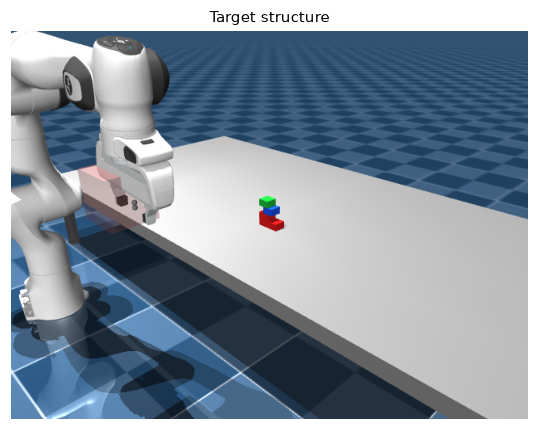

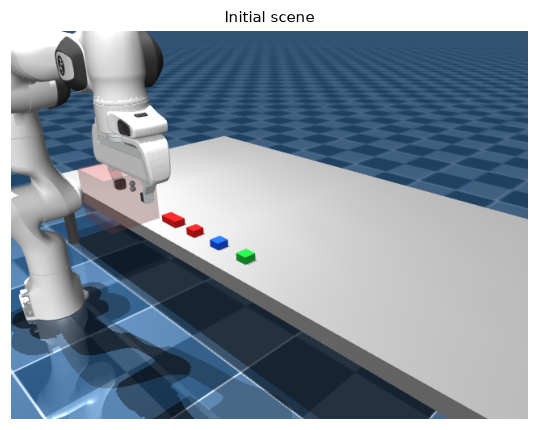

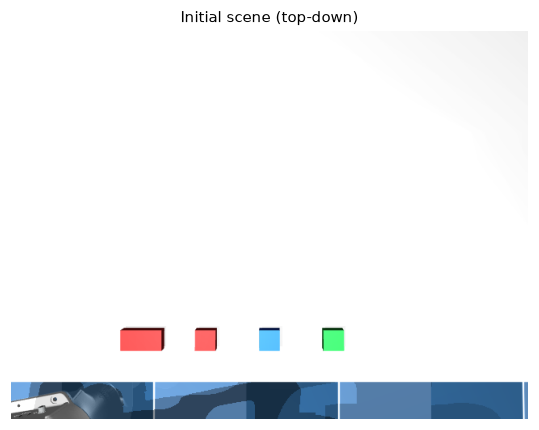

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.

Planned for 0.058s

PLAN:
  ('pick', ('b_2x2_brick_3', 'pick_2x2_brick_3'))
  ('stack', ('b_2x2_brick_3', 'b_2x2_brick_2'))
  ('pick', ('b_2x2_brick_4', 'pick_2x2_brick_4'))
  ('stack', ('b_2x2_brick_4', 'b_2x2_brick_3'))
  ('pick', ('b_4x2_brick_1', 'pick_4x2_brick_1'))
  ('place', ('b_4x2_bri

In [7]:
task = DATASET + "/tier2/task_100.yaml"
scene = build_scene(task_path=task)
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks = list(scene.bricks.values())
bb = LegoCoarseSimpleSLSBridge()  # bridge builder

# get bridge and objects/goals
bridge = bb.make_bridge("domains/lego_coarse_simple.pddl", scene)
objects, goals = bb.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

# show target structure and initial scene
scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

start_t = time.time()
plan = bridge.plan(objects, goals)
wall_time = time.time() - start_t
print(f"Planned for {wall_time:.3f}s")
print("\nPLAN:")
for step in plan:
    print(" ", step)

In [17]:
from IPython.display import Video

# Video(RESULTS + "demos/slots_bad_layer_order.mp4", embed=True)

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[1/16] pick(b_2x2_brick_3, pick_2x2_brick_3) -> ok


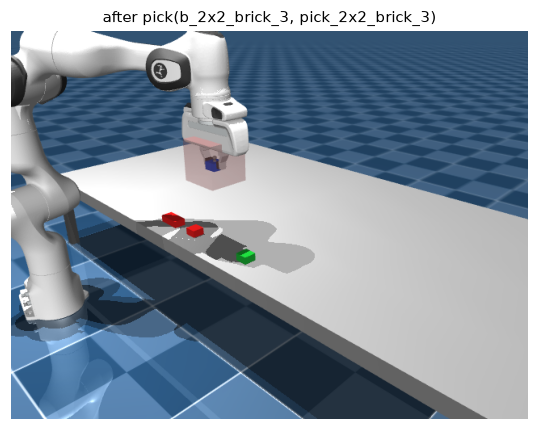

[PickPlaceExecutor] place SUCCESS
[2/16] stack(b_2x2_brick_3, b_2x2_brick_2) -> ok


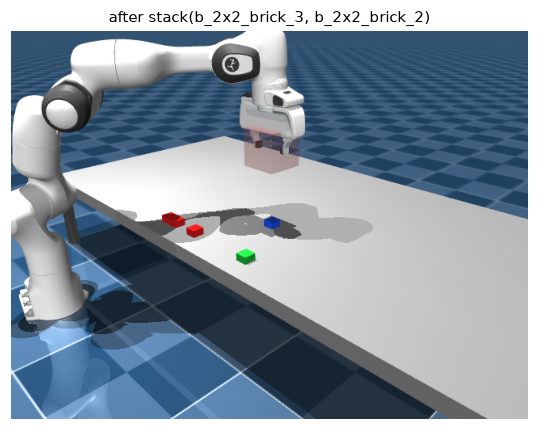

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.3 mm
  pick SUCCESS
[3/16] pick(b_2x2_brick_4, pick_2x2_brick_4) -> ok


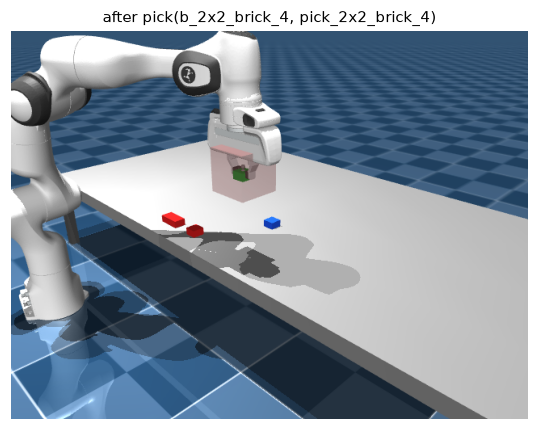

[PickPlaceExecutor] place SUCCESS
[4/16] stack(b_2x2_brick_4, b_2x2_brick_3) -> ok


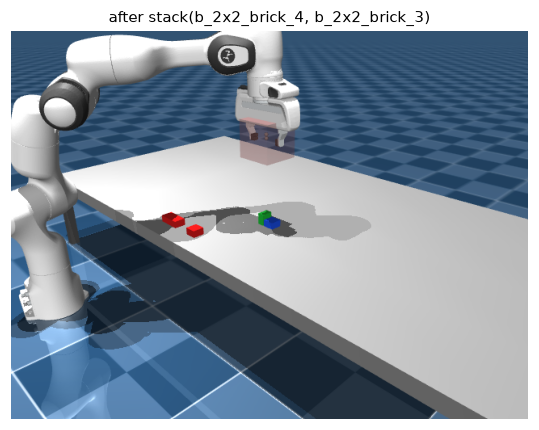

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[5/16] pick(b_4x2_brick_1, pick_4x2_brick_1) -> ok


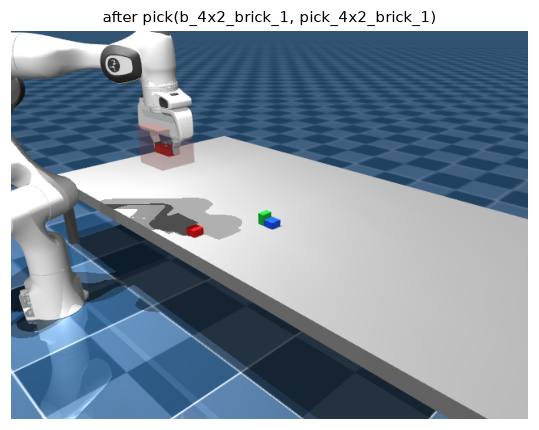

[PickPlaceExecutor] place descent plan failed
[PickPlaceExecutor] place descent plan failed
[6/16] place(b_4x2_brick_1, asm_4x2_brick_1) -> FAILED


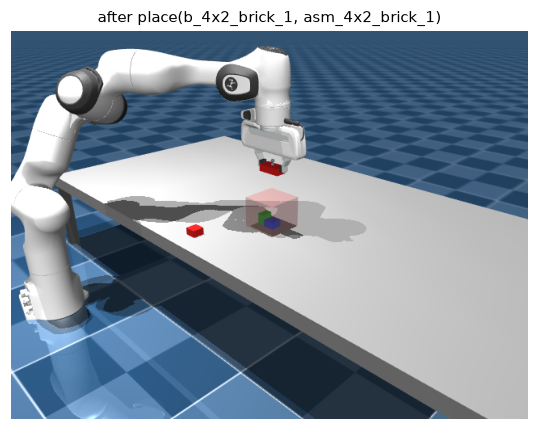


executed: False


In [ ]:
# TODO: maybe better to execute with recording and then play gif (image by image takes a lot of space)


ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

**TODO** comments
- slipping + unstacking wrong as assumption is that brick at target

---

### **2. `domains/lego_coarse_simple_v2.pddl`**

Script executed in `src/`:
```bash
python eval.py --tiers tier1 tier2 --bridge simple_v2 --workers 6 --out generated/evals/simple_v2_t12.csv
```

In [9]:
simple_v2_df = pd.read_csv(RESULTS + "/evals/simple_v2_t12.csv")
simple_v2_df

,tier,task,n_bricks,planned,plan_time_s,plan_len,executed,exec_time_s,goal_ok,max_dxy_mm,max_dyaw_deg,error
0,tier1,task_001,2,True,0.08,4,True,29.4,True,2.03,0.13,NaN
1,tier2,task_001,3,True,0.05,6,True,42.9,True,1.99,0.21,NaN
2,tier1,task_002,2,True,0.05,4,True,29.4,True,1.93,0.11,NaN
3,tier2,task_002,3,True,0.44,6,True,42.7,False,81.44,0.21,NaN
4,tier1,task_003,2,True,0.05,4,True,29.4,True,2.03,0.13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
195,tier2,task_098,2,True,2.48,4,True,29.7,True,2.21,0.09,NaN
196,tier1,task_099,2,True,0.05,4,True,29.4,True,1.93,0.11,NaN
197,tier2,task_099,3,True,0.83,6,True,43.9,True,1.97,0.19,NaN
198,tier1,task_100,2,True,0.04,4,True,29.1,True,2.03,0.13,NaN


In [10]:
simple_v2_df.groupby("tier").agg({"goal_ok": "sum"})

,goal_ok
tier,
tier1,100
tier2,63


In [12]:
simple_v2_df[simple_v2_df.goal_ok == False]

,tier,task,n_bricks,planned,plan_time_s,plan_len,executed,exec_time_s,goal_ok,max_dxy_mm,max_dyaw_deg,error
3,tier2,task_002,3,True,0.44,6,True,42.7,False,81.44,0.21,NaN
11,tier2,task_006,3,True,0.02,6,True,42.8,False,13.42,5.87,NaN
15,tier2,task_008,3,True,0.03,6,True,42.8,False,13.42,5.87,NaN
17,tier2,task_009,4,True,0.04,8,True,57.1,False,80.87,0.29,NaN
27,tier2,task_014,3,True,0.03,6,True,42.8,False,13.42,5.87,NaN
33,tier2,task_017,3,True,0.02,6,True,43.0,False,35.87,0.49,NaN
37,tier2,task_019,3,True,0.05,6,True,42.8,False,13.42,5.87,NaN
39,tier2,task_020,4,True,0.03,8,True,55.9,False,83.02,0.26,NaN
45,tier2,task_023,3,True,0.08,6,True,42.8,False,35.87,0.49,NaN
47,tier2,task_024,3,True,0.11,6,True,42.8,False,81.44,0.21,NaN


We see that we don't fail because of unstack errors, however the goal is still not reached often although we "succeeded" in execution.
The reason is that the blocks slip when placed, for example due to overhang.

Loaded dataset/ground_truth/tier2/task_100.yaml
objects: {'brick': ['b_4x2_brick_1', 'b_2x2_brick_2', 'b_2x2_brick_3', 'b_2x2_brick_4'], 'location': ['pick_4x2_brick_1', 'pick_2x2_brick_2', 'pick_2x2_brick_3', 'pick_2x2_brick_4', 'asm_4x2_brick_1']}
goals:   [('at', 'b_4x2_brick_1', 'asm_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_2', 'b_4x2_brick_1'), ('stacked_on', 'b_2x2_brick_3', 'b_2x2_brick_2'), ('stacked_on', 'b_2x2_brick_4', 'b_2x2_brick_3')]


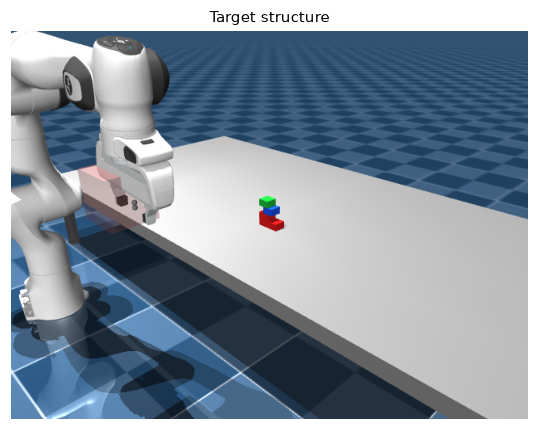

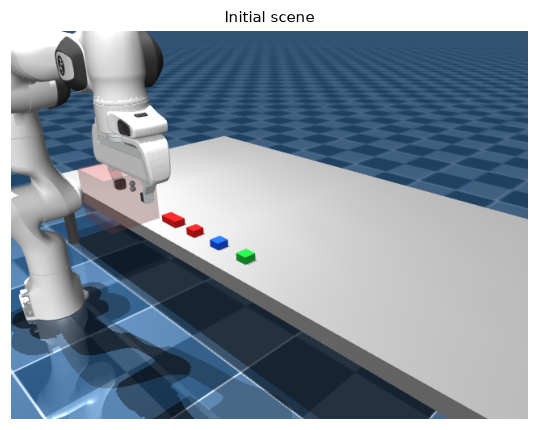

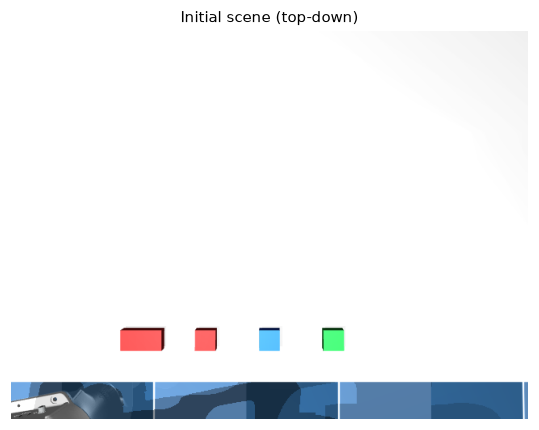

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.

Planned for 0.066s

PLAN:
  ('pick', ('b_2x2_brick_3', 'pick_2x2_brick_3'))
  ('stack', ('b_2x2_brick_3', 'b_2x2_brick_2'))
  ('pick', ('b_2x2_brick_4', 'pick_2x2_brick_4'))
  ('stack', ('b_2x2_brick_4', 'b_2x2_brick_3'))
  ('pick', ('b_4x2_brick_1', 'pick_4x2_brick_1'))
  ('place', ('b_4x2_brick_1', 'asm_4x2_brick_1'))
  ('unstack', ('b_2x2_brick_4', 'b_2x2_brick_3'))
  ('place', ('b_2x2_brick_4', 'pick_2x2_brick_3'))
  ('unsta

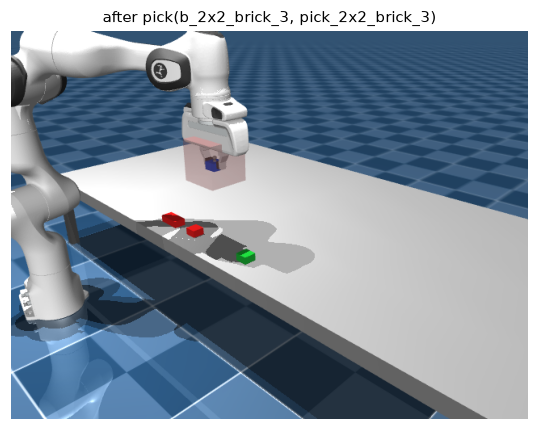

[PickPlaceExecutor] place SUCCESS
[2/16] stack(b_2x2_brick_3, b_2x2_brick_2) -> ok


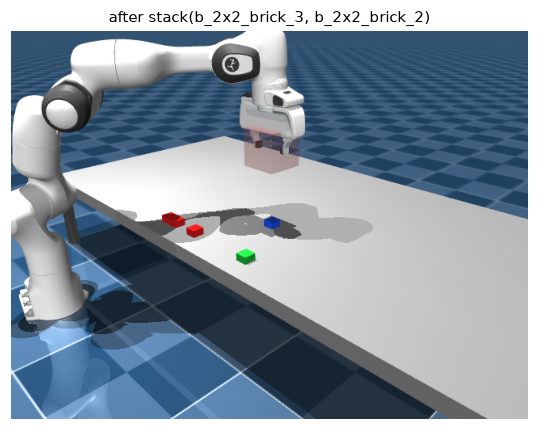

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.3 mm
  pick SUCCESS
[3/16] pick(b_2x2_brick_4, pick_2x2_brick_4) -> ok


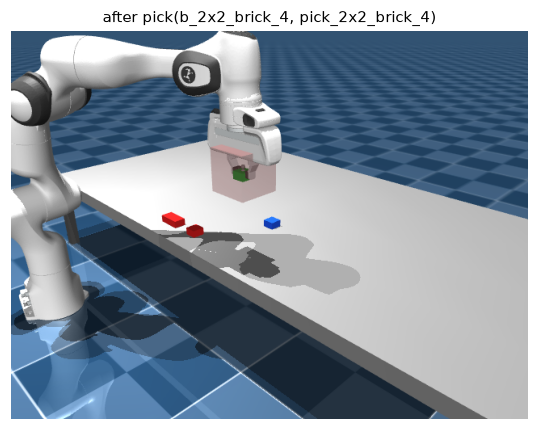

[PickPlaceExecutor] place SUCCESS
[4/16] stack(b_2x2_brick_4, b_2x2_brick_3) -> ok


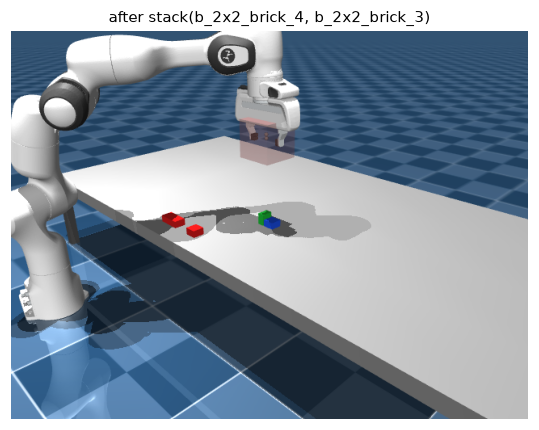

[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.6 mm
  pick SUCCESS
[5/16] pick(b_4x2_brick_1, pick_4x2_brick_1) -> ok


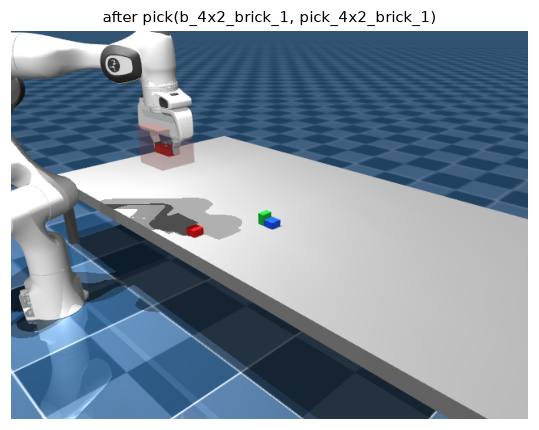

[PickPlaceExecutor] place descent plan failed
[PickPlaceExecutor] place descent plan failed
[6/16] place(b_4x2_brick_1, asm_4x2_brick_1) -> FAILED


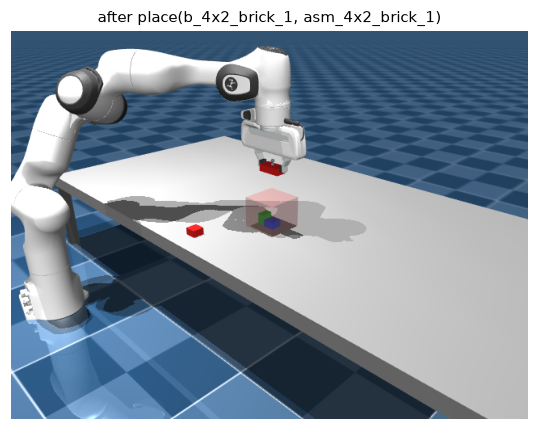


executed: False


In [13]:
task = DATASET + "/tier2/task_100.yaml"
scene = build_scene(task_path=task)
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks = list(scene.bricks.values())
bb = LegoCoarseSimpleSLSBridge()  # bridge builder

# get bridge and objects/goals
bridge = bb.make_bridge("domains/lego_coarse_simple.pddl", scene)
objects, goals = bb.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

# show target structure and initial scene
scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

start_t = time.time()
plan = bridge.plan(objects, goals)
wall_time = time.time() - start_t
print(f"Planned for {wall_time:.3f}s")
print("\nPLAN:")
for step in plan:
    print(" ", step)


ok, n = True, 0
for i, (name, args) in enumerate(plan):
    success, _ = bridge.execute_action(name, *args)
    print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
    show_scene(scene.env, f"after {name}({', '.join(args)})")
    if not success:
        ok, n = False, i
        break
else:
    n = len(plan)

print("\nexecuted:", ok)

---

### **3.1. `domains/lego_coarse_simple_v2.pddl` with Snapping and Welds**

Script executed in `src/`:
```bash
python eval.py --tiers tier1 tier2 --bridge simple_v2_welds --workers 6 --out generated/evals/simple_v2_welds_t12.csv
```

In [14]:
# TODO